# 08 · Cohorts & vertex-wise statistics

**SpectralBrain tutorial series — notebook 7 of 9.** (Previous: functional maps & distances.)

The series now turns from geometry to **inference**. We load a cohort with
`load_group`, then test where a descriptor differs across the surface, with honest
control of the multiple-comparisons problem: max-statistic permutation (family-wise
error), false-discovery control, and threshold-free cluster enhancement.

### Learning objectives
1. Assemble a cohort into a `GroupData` object with `load_group`.
2. Understand why vertex-wise testing needs multiple-comparison correction.
3. Apply `vertexwise_ttest` (FDR), `vertexwise_permutation` (FWE), `cohens_d_map`, and `tfce`.

> **Note on sample size.** This teaching dataset has only a handful of real
> subjects, far too few for a real group contrast. Sections 1 loads the *real*
> cohort to show the machinery; sections 3–5 then use a **clearly-labelled
> synthetic cohort built on the real template geometry**, with a planted effect,
> so the statistics have something to find. Synthetic data is used only to
> demonstrate the methods, never to make a scientific claim.


## 1. Loading a cohort

`load_group` takes a set of inputs and returns a `GroupData`. With
`mode='pipeline'` it runs the spectral pipeline on each subject and stacks the
result. HippUnfold `den-8k` surfaces share a common topology, so their vertices
correspond across subjects, which is exactly what vertex-wise statistics require.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
import scipy.sparse as sp
import spectralbrain as sb
import spectralbrain.statistics as st
from _tutorial_utils import data_path

files = {f"{s}_{h}": data_path("hippunfold", s,
            f"hemi-{h}_space-T1w_den-8k_label-hipp_midthickness.surf.gii")
         for s in ["sub03", "sub04"] for h in ["L", "R"]}
group = sb.load_group(files, mode="pipeline", descriptor="shapedna", k=60)
print(f"GroupData: {group.n_subjects} subjects, descriptor matrix {group.data.shape}")
print(f"subjects: {group.subject_ids}")

[06/09/26 02:11:02] INFO     Laplacian (cotangent): N=8192, nnz=56578

[06/09/26 02:11:03] INFO     Laplacian (cotangent): N=8192, nnz=56578

                    INFO     Laplacian (cotangent): N=8192, nnz=56578

[06/09/26 02:11:04] INFO     Laplacian (cotangent): N=8192, nnz=56578

[06/09/26 02:11:04] INFO     Loaded group: 4/4 subjects (mode=pipeline).

GroupData: 4 subjects, descriptor matrix (4, 59)
subjects: ['sub03_L', 'sub03_R', 'sub04_L', 'sub04_R']


## 2. The multiple-comparisons problem

A `den-8k` hippocampus has ~8,000 vertices. Testing each independently at
$\alpha=0.05$ would yield ~400 false positives by chance alone. Three standard
remedies, all in SpectralBrain:

- **FDR** (Benjamini–Hochberg): controls the *expected proportion* of false
  positives among the rejections. Most sensitive, weakest guarantee.
- **FWE by max-statistic permutation** (Nichols & Holmes 2002): controls the
  probability of *any* false positive, by comparing each vertex to the null
  distribution of the *maximum* statistic over the whole surface. Strong guarantee.
- **TFCE** (Smith & Nichols 2009): enhances spatially contiguous signal without a
  hard cluster threshold, then tested by permutation.

We build a template-based synthetic cohort to see them work.

In [2]:
# Real template geometry: a left hippocampus and its HKS field.
mesh = sb.BrainMesh(*sb.load_gifti_surface(files["sub03_L"]))
dec = mesh.decompose(k=200)
template = np.asarray(sb.compute_hks(dec, n_times=100))[:, 60]   # one HKS scale, per vertex
template = (template - template.mean()) / template.std()
N = mesh.n_vertices

# Plant a focal effect at one end of the hippocampus (e.g. the head).
head = mesh.vertices[:, 0] > np.percentile(mesh.vertices[:, 0], 80)
print(f"planted-effect region: {head.sum()} of {N} vertices")

rng = np.random.default_rng(42)
n_per = 16
A = template[None, :] + rng.normal(0, 1.0, (n_per, N))            # controls
B = template[None, :] + rng.normal(0, 1.0, (n_per, N))            # patients
B[:, head] += 1.2                                                 # focal group difference
print(f"synthetic cohort: group A {A.shape}, group B {B.shape}  (SYNTHETIC — teaching only)")

[06/09/26 02:11:05] INFO     Laplacian (cotangent): N=8192, nnz=56578

planted-effect region: 1639 of 8192 vertices
synthetic cohort: group A (16, 8192), group B (16, 8192)  (SYNTHETIC — teaching only)


## 3. Three corrections, compared

We run the parametric $t$-test with FDR, the permutation test with FWE max-stat
control, and read off how many vertices each declares significant. FWE is the most
conservative; FDR the most permissive; both should localise to the planted head
region.

In [3]:
res_fdr = st.vertexwise_ttest(A, B, correction="fdr", alpha=0.05)
res_fwe = st.vertexwise_permutation(A, B, n_permutations=2000, correction="max", seed=0, alpha=0.05)
d_map = np.asarray(st.cohens_d_map(A, B))

print(f"FDR  significant vertices: {int(res_fdr.n_significant):4d}")
print(f"FWE  significant vertices: {int(res_fwe.n_significant):4d}")
print(f"max |Cohen's d|: {np.abs(d_map).max():.2f}  "
      f"(planted region mean d = {d_map[head].mean():.2f}, elsewhere = {d_map[~head].mean():.2f})")

# fraction of detections that fall inside the planted region (precision)
for name, res in [("FDR", res_fdr), ("FWE", res_fwe)]:
    sigv = np.asarray(res.significant)
    if sigv.sum():
        print(f"  {name}: {100*sigv[head].sum()/sigv.sum():.0f}% of significant vertices lie in the planted region")

Output()

FDR  significant vertices: 1214
FWE  significant vertices:   88
max |Cohen's d|: 2.67  (planted region mean d = -1.25, elsewhere = -0.00)
  FDR: 96% of significant vertices lie in the planted region
  FWE: 100% of significant vertices lie in the planted region


## 4. TFCE: cluster-free spatial enhancement

TFCE boosts vertices that sit in spatially extended regions of signal, using the
mesh adjacency. We build adjacency from the surface faces and enhance the $t$-map.

In [4]:
F = mesh.faces
rows = np.concatenate([F[:, 0], F[:, 1], F[:, 2], F[:, 1], F[:, 2], F[:, 0]])
cols = np.concatenate([F[:, 1], F[:, 2], F[:, 0], F[:, 0], F[:, 1], F[:, 2]])
adj = sp.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
adj = (adj > 0).astype(float)

tfce_map = np.asarray(st.tfce(res_fwe.statistic, adj))
print(f"TFCE map: range {tfce_map.min():.2f} .. {tfce_map.max():.2f}")
print(f"TFCE signal concentrated in planted region? "
      f"mean inside={tfce_map[head].mean():.2f} vs outside={tfce_map[~head].mean():.2f}")

TFCE map: range 0.00 .. 537.41
TFCE signal concentrated in planted region? mean inside=284.31 vs outside=8.01


## 5. Mapping the result

The whole point of vertex-wise analysis is *localisation*. We render the Cohen's d
map and the TFCE map on the surface with the six-view tool. The signal should
light up exactly the planted head region, which is how you would read a real
group difference in, say, hippocampal sclerosis.

2026-06-09 02:11:20.145 (   0.313s) [    7F69ABDB2080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


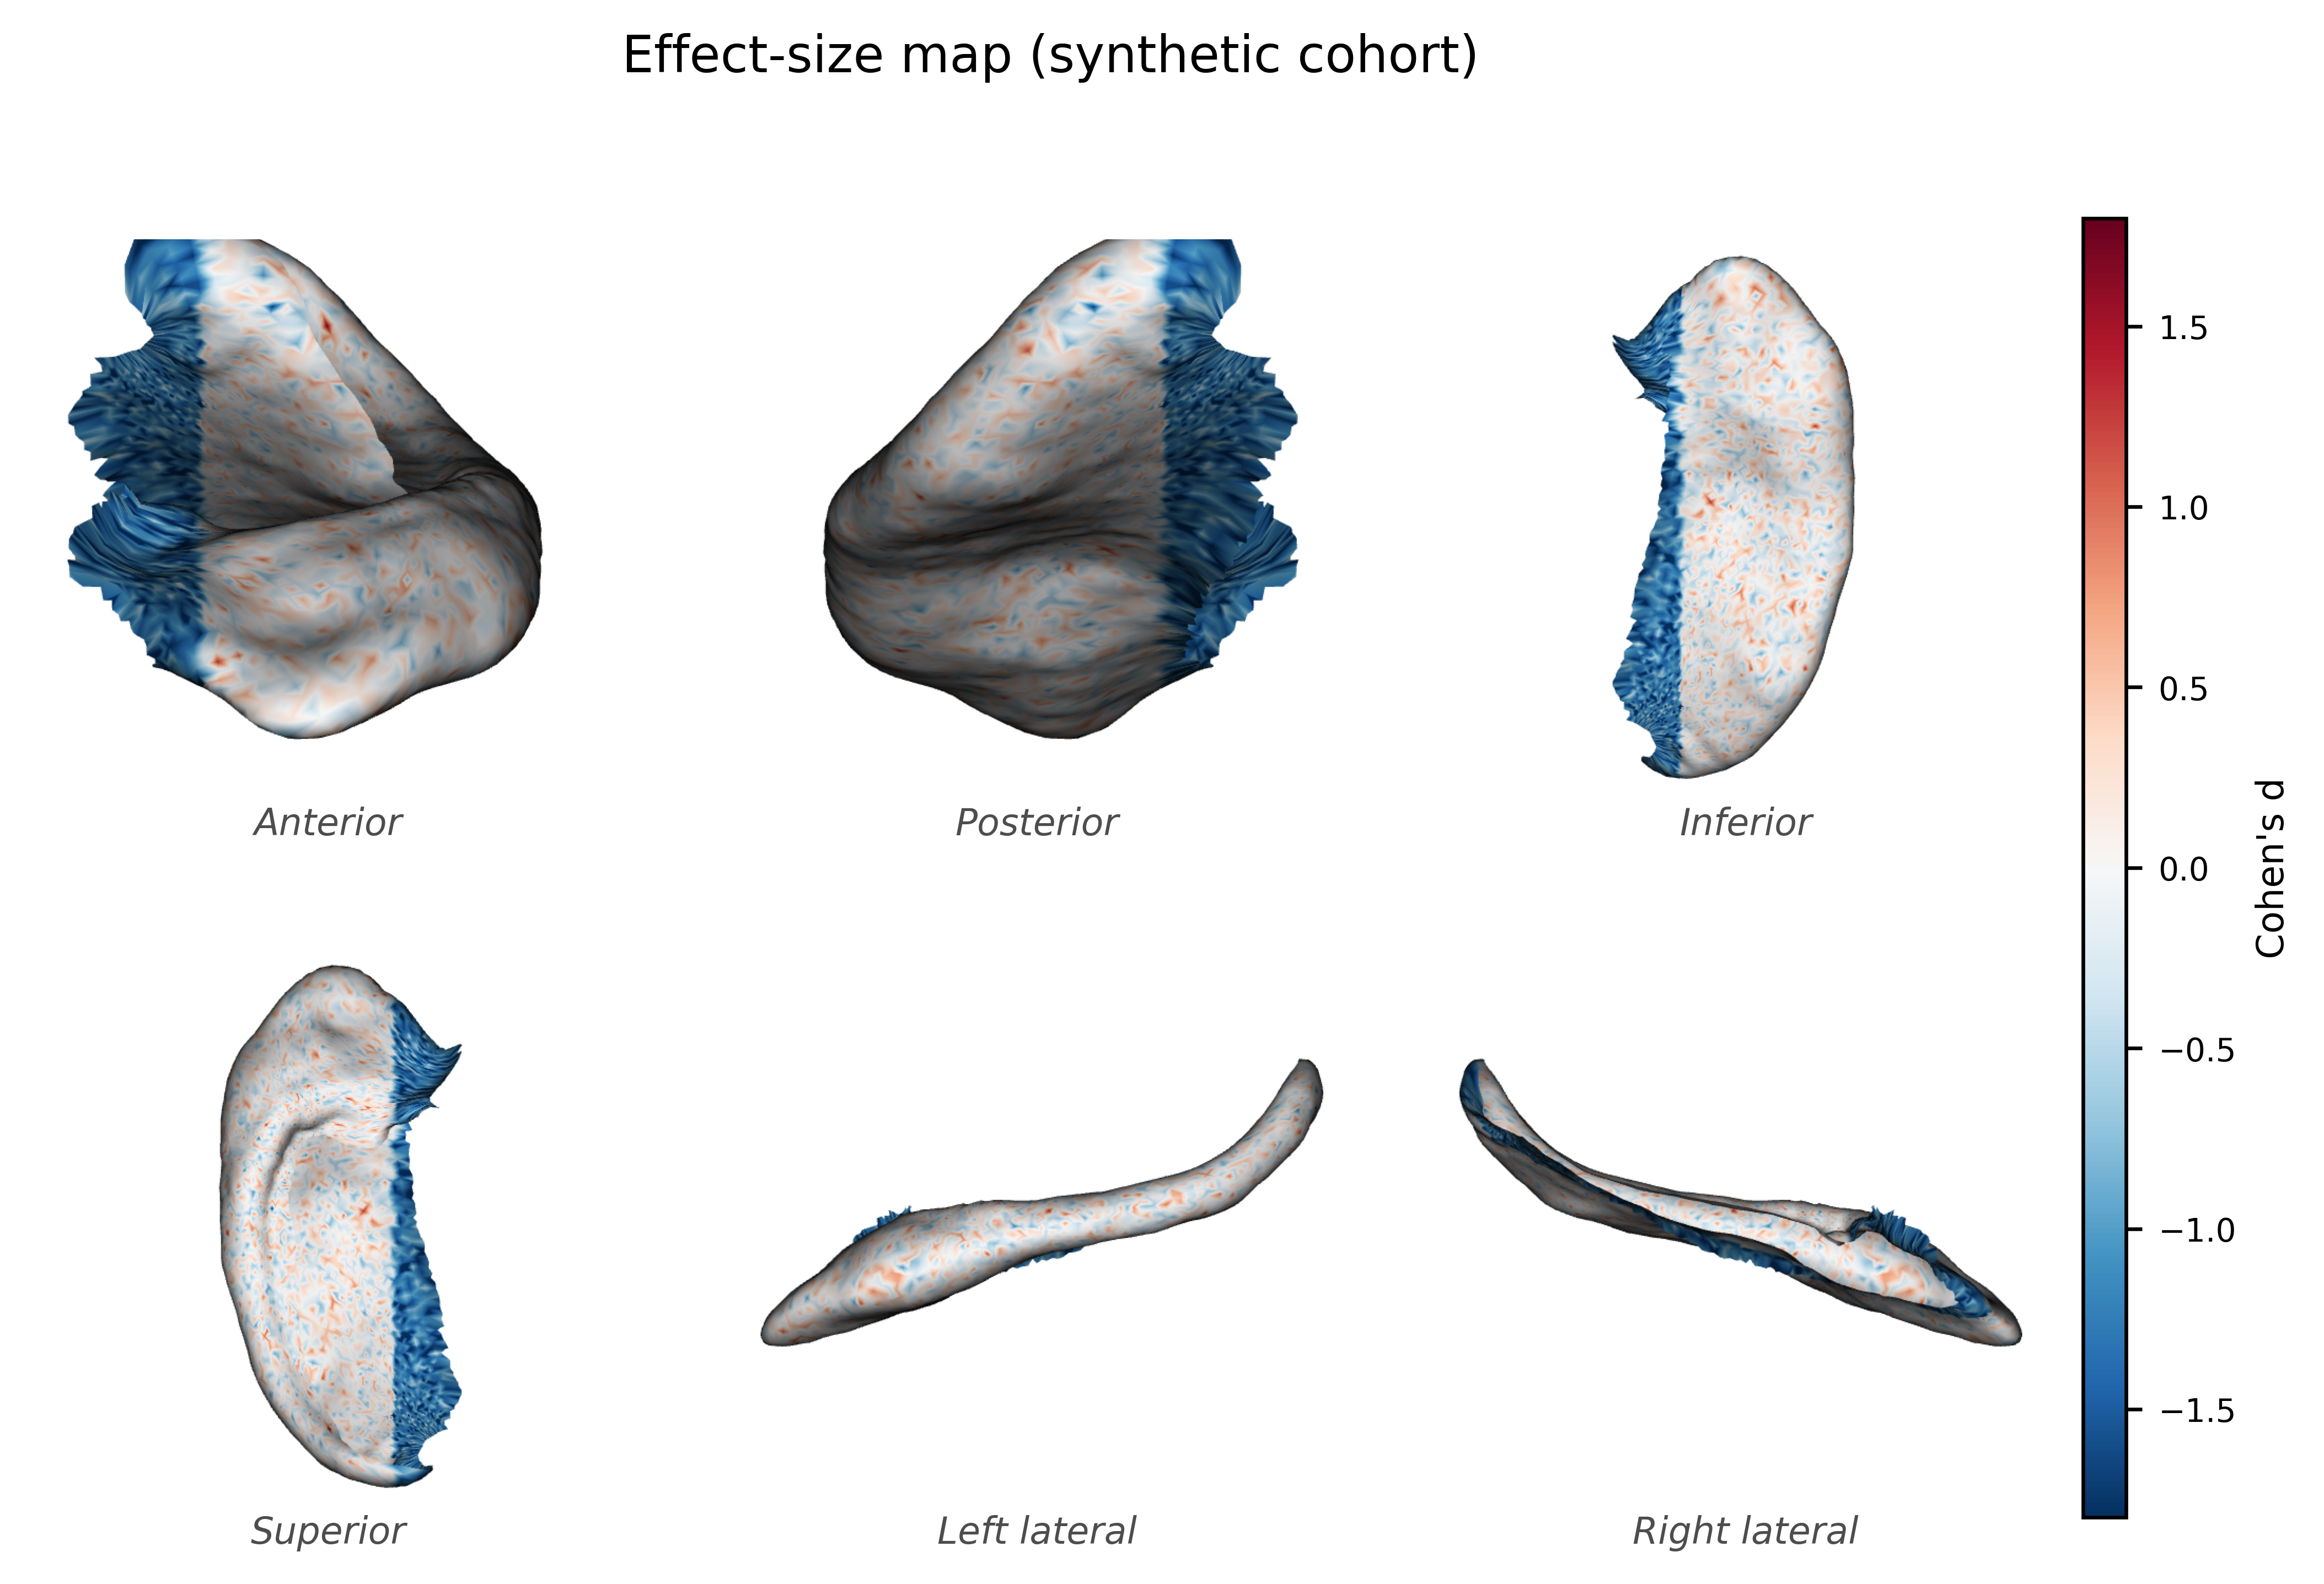

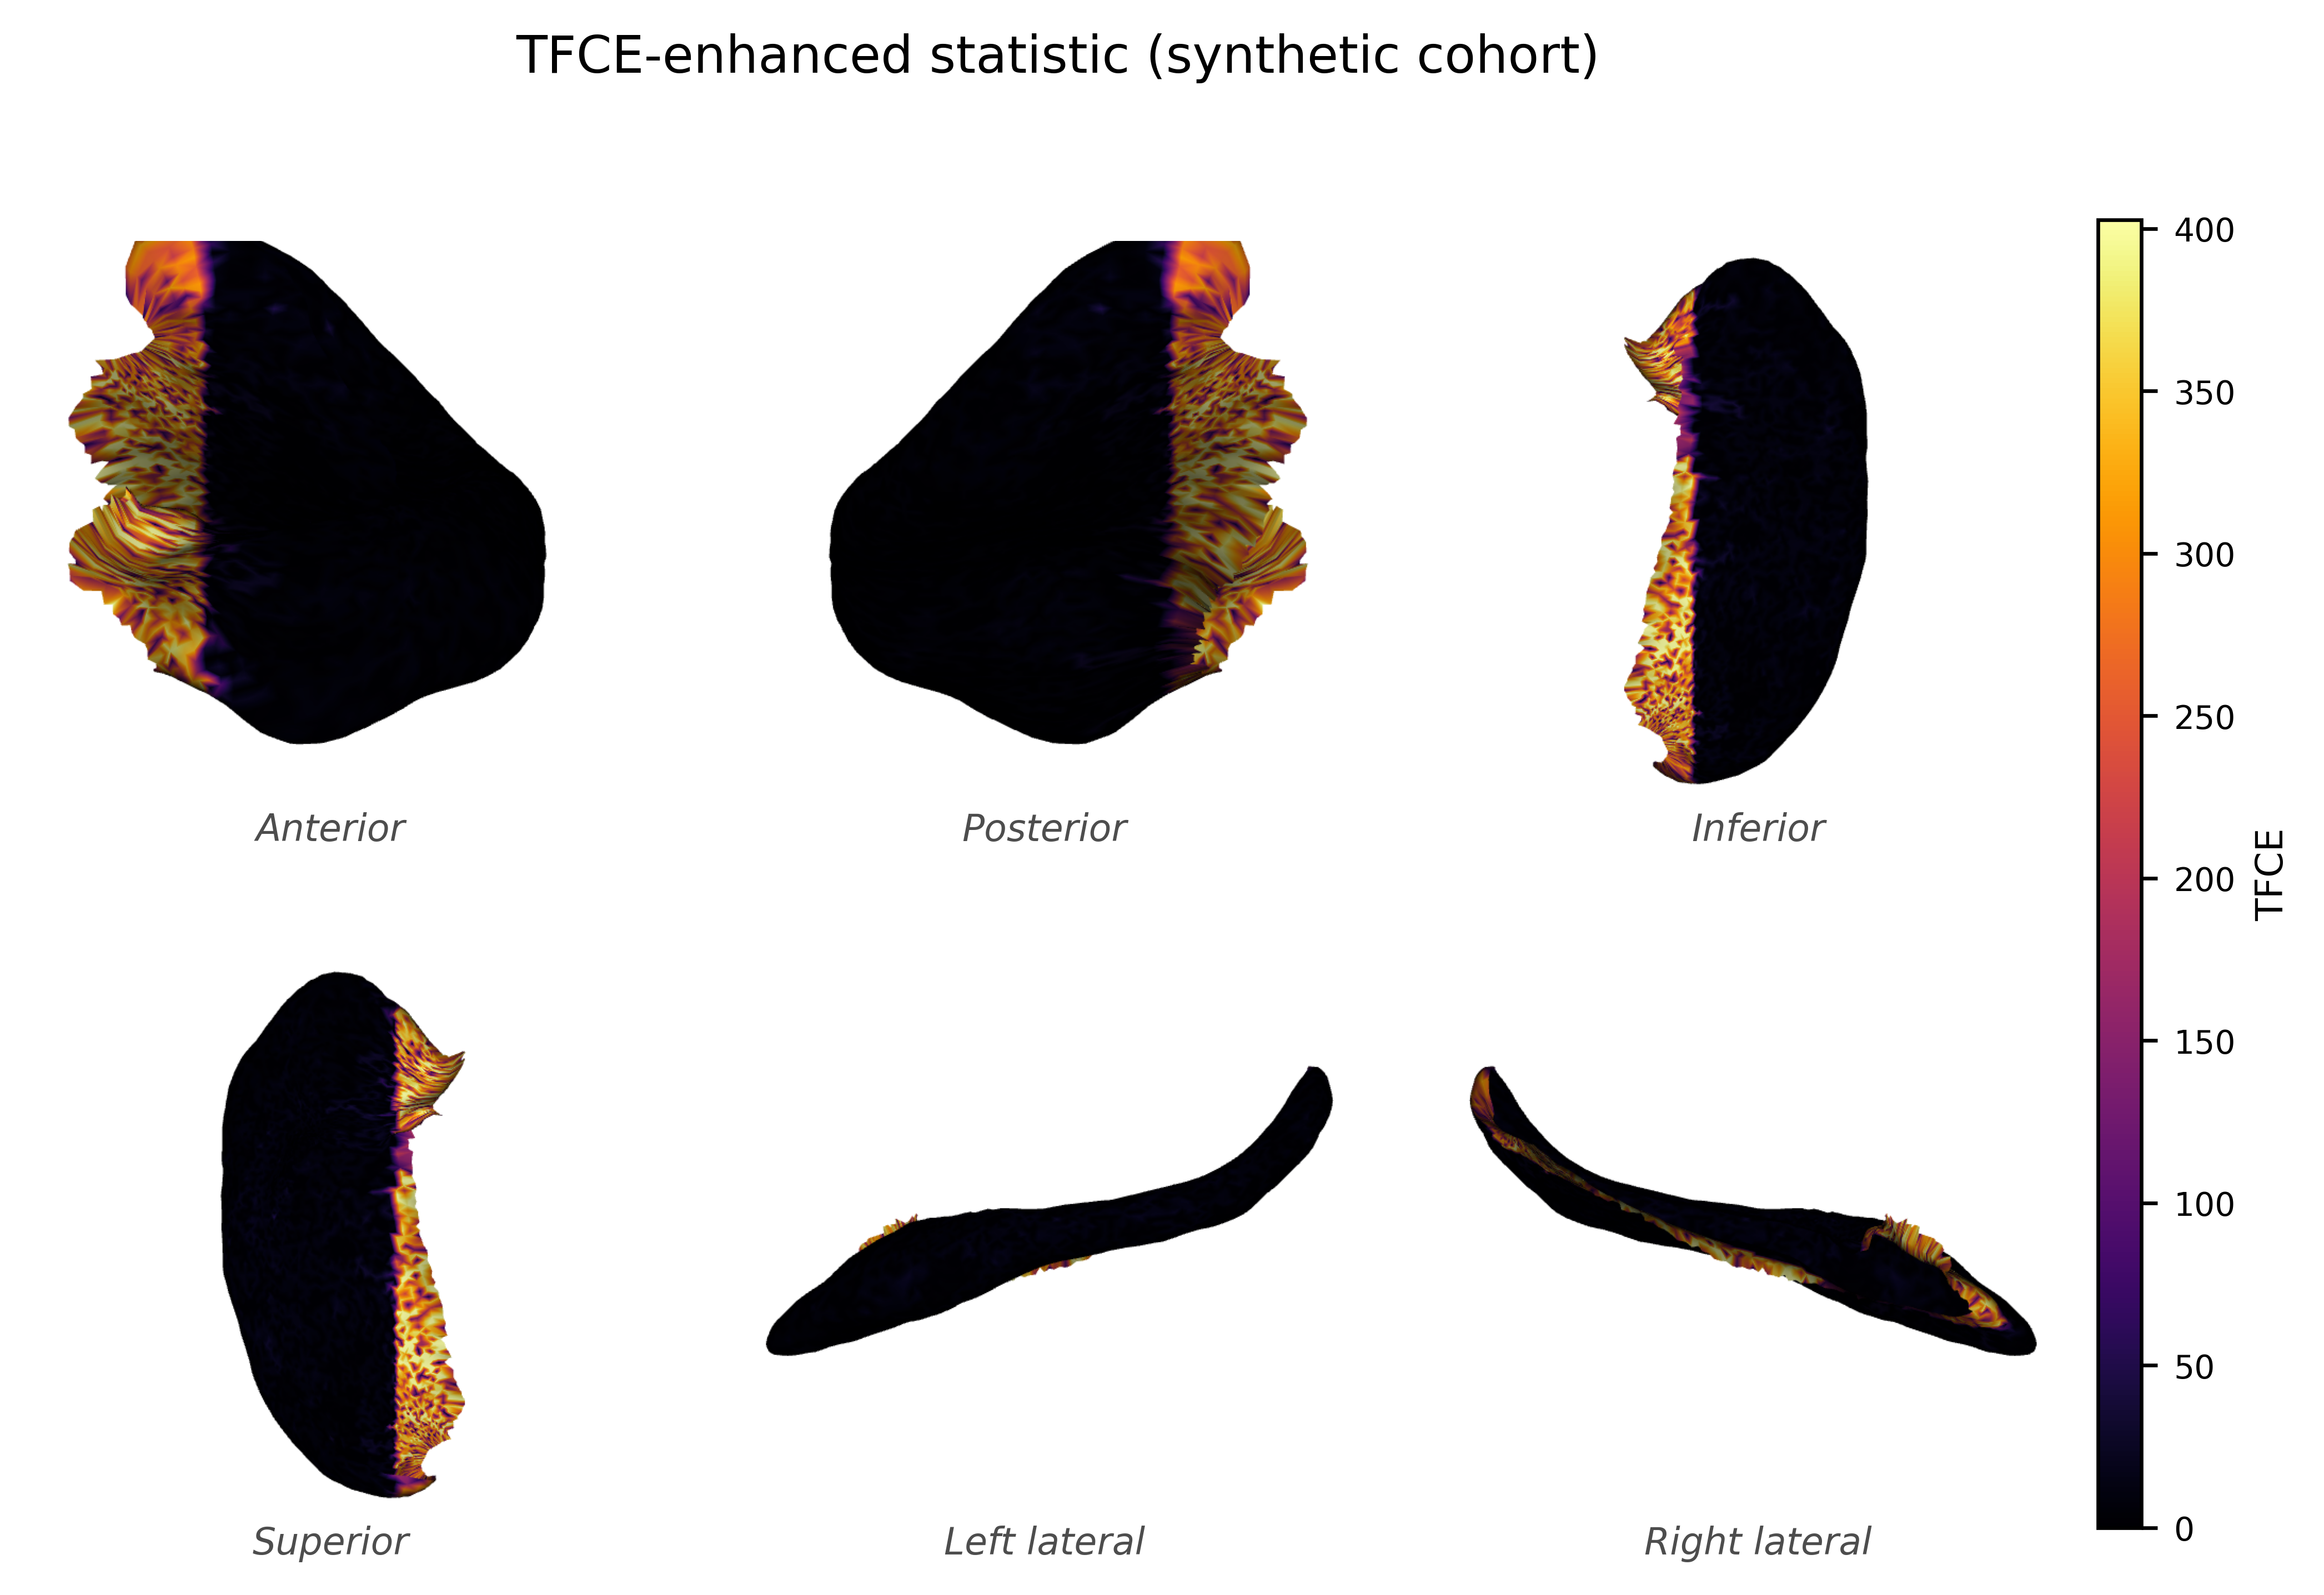

In [5]:
from spectralbrain.viz import plot_surface_sixview
fig = plot_surface_sixview(mesh, scalars=d_map, cmap="RdBu_r", signed=True,
                           scalar_bar_title="Cohen's d", title="Effect-size map (synthetic cohort)")
plt.show()
fig = plot_surface_sixview(mesh, scalars=tfce_map, cmap="inferno",
                           scalar_bar_title="TFCE", title="TFCE-enhanced statistic (synthetic cohort)")
plt.show()

## Exercises

1. **Effect size vs n.** Halve the planted effect (`+0.6` instead of `+1.2`) and
   re-run. Which correction still detects it — FDR, FWE, or neither?
2. **Where is the signal?** Plant the effect in the hippocampal *tail*
   (`< 20th percentile` of x) instead of the head and confirm the maps follow.
3. **Permutation count.** Re-run `vertexwise_permutation` with 500 vs 5000
   permutations. How stable is `n_significant`? What does the count buy you?
4. **Correlation, not contrast.** Use `vertexwise_correlation` to relate the
   per-vertex HKS to a synthetic continuous score across subjects, with FDR.
5. **Real cohort.** Replace the synthetic data with the four real subjects' HKS
   maps (`load_group(..., descriptor='hks')`) and a left-vs-right contrast. Why is
   nothing significant, and what would you need to change?


## What's next

Vertex-wise maps tell us *where*. **Notebook 08** quantifies *how much* and *how
reliably*: DeLong's test for comparing classifier AUCs, bias-corrected bootstrap
intervals, intraclass correlation for reliability, cross-validated classification,
and multi-site harmonisation with ComBat.
